In [4]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from hydrosense.ades import GestionnairePiezometrie

### Téléchargement Piezo

- Nouveau Code National BSS : BSS001QHYH
- Ancien Code BSS (Indice) : 06352X0032/S
- Nom sur les bases de données (ADES / HubEAU) : BOURDET (situé au lieu-dit La Jannerie)
- Entité Hydrogéologique : Calcaires du Jurassique supérieur (Aquifère du secteur Aunis)

In [ ]:
bss_id = 'BSS001QHYH'
# bss_id  = 'BSS001PGUQ'

gestionnaire = GestionnairePiezometrie(dossier_sortie="../raw_data")
gestionnaire.telecharger_bassin_versant([bss_id])

--- Début du traitement pour 1 forages ---
Info: données BSS001QHYH déja présente
--- Traitement du bassin versant terminé ! ---


In [5]:
df = pd.read_csv(f'../raw_data/piezo_{bss_id}.csv', sep = ';')
# df = df.set_index('date_mesure')
df['date_mesure'] = pd.to_datetime(df['date_mesure'])

df.head()

,date_mesure,niveau_nappe_eau,profondeur_nappe
0,1985-06-24,12.54,2.68
1,1985-06-25,12.54,2.68
2,1985-06-26,12.54,2.68
3,1985-06-27,12.54,2.68
4,1985-06-28,12.51,2.71


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14532 entries, 0 to 14531
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date_mesure       14532 non-null  datetime64[ns]
 1   niveau_nappe_eau  14532 non-null  float64       
 2   profondeur_nappe  14532 non-null  float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 340.7 KB


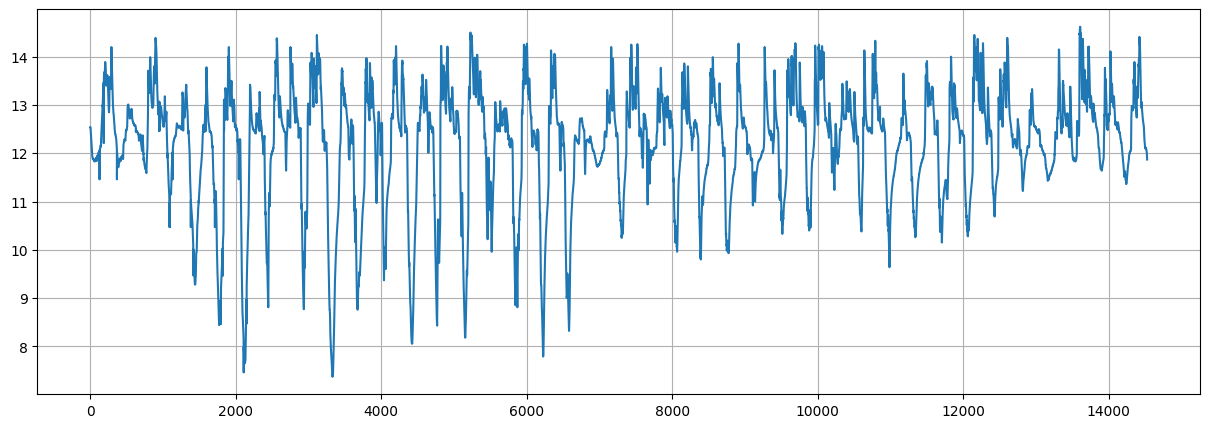

In [7]:
df['niveau_nappe_eau'].plot(kind = 'line', figsize=(15,5))
plt.grid(True)

## Verification Package Darts

Version de Darts : 0.44.1

TODO : Est-ce que pyTorch package est nécessaire ?? 
-> Demander à Gemini

In [8]:
import darts
from darts import TimeSeries
from darts.models import RNNModel

print(f"Version de Darts : {darts.__version__}")

# Failed Torch test.
if False:
    import torch
    print(f"PyTorch est-il prêt ? {torch.__version__}")
    print(f"GPU disponible pour PyTorch ? {torch.cuda.is_available()}")


Version de Darts : 0.44.1


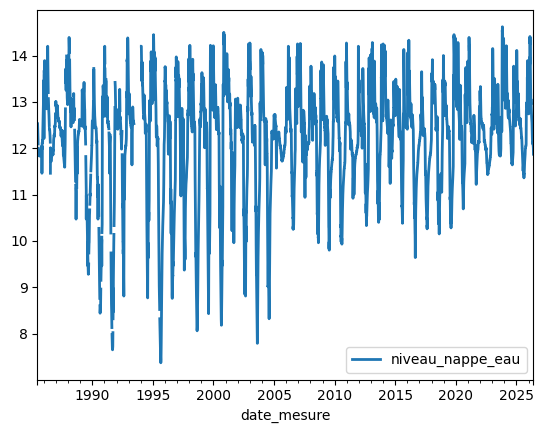

In [9]:
series = TimeSeries.from_dataframe(df, time_col= 'date_mesure',
                                   value_cols= 'niveau_nappe_eau',
                                   fill_missing_dates=True,
                                   freq= 'D'
                                   )
series.plot();

## Explore Météo

In [17]:
file_climat = '../data/Q_17_previous-1950-2024_RR-T-Vent.csv'

df_climat = pd.read_csv(file_climat, sep = ';')
df_climat['DATE'] = pd.to_datetime(df_climat['AAAAMMJJ'].astype(str), format='%Y%m%d')


FileNotFoundError: [Errno 2] No such file or directory: '../data/Q_17_previous-1950-2024_RR-T-Vent.csv'

#### Localisation et Métadonnées


- NUM_POSTE : Identifiant unique de la station météo (code INSEE + numéro).
- NOM_USUEL : Nom de la commune ou de la station (ex: LA ROCHELLE).
- LAT / LON / ALTI : Latitude, Longitude et Altitude (en mètres) de la station.

🌡️ Températures (en °C)
- TN : Température minimale sous abri.
- TX : Température maximale sous abri.
- TM : Température moyenne.


🌧️ Précipitations
- RR : Hauteur des précipitations (la pluie) du jour, mesurée en millimètres (mm).


💨 Vent (en m/s)
- FFM : Force du vent moyen à 10 mètres de haut.

Les stations n'ont pas de la données sur toutes les mêmes durées. Il y a du tri et du remplissage à faire.

In [54]:
print(df_climat.columns)
df_climat['NUM_POSTE'].unique()

Index(['NUM_POSTE', 'NOM_USUEL', 'LAT', 'LON', 'ALTI', 'AAAAMMJJ', 'RR', 'QRR',
       'TN', 'QTN', 'HTN', 'QHTN', 'TX', 'QTX', 'HTX', 'QHTX', 'TM', 'QTM',
       'TNTXM', 'QTNTXM', 'TAMPLI', 'QTAMPLI', 'TNSOL', 'QTNSOL', 'TN50',
       'QTN50', 'DG', 'QDG', 'FFM', 'QFFM', 'FF2M', 'QFF2M', 'FXY', 'QFXY',
       'DXY', 'QDXY', 'HXY', 'QHXY', 'FXI', 'QFXI', 'DXI', 'QDXI', 'HXI',
       'QHXI', 'FXI2', 'QFXI2', 'DXI2', 'QDXI2', 'HXI2', 'QHXI2', 'FXI3S',
       'QFXI3S', 'DXI3S', 'QDXI3S', 'HXI3S', 'QHXI3S', 'DRR', 'QDRR',
       'STATUS_FXI3S', 'STATUS_DXI3S', 'DATE'],
      dtype='object')


array([17003001, 17004001, 17009001, 17010001, 17016002, 17050001,
       17053001, 17060001, 17068001, 17072001, 17086001, 17093002,
       17111001, 17121001, 17127003, 17132001, 17142001, 17166001,
       17168001, 17172001, 17197001, 17218001, 17224001, 17225001,
       17225002, 17225003, 17226001, 17236001, 17240001, 17241001,
       17243002, 17248001, 17253001, 17266001, 17268002, 17283003,
       17284001, 17299001, 17300001, 17300004, 17300005, 17300006,
       17300009, 17300010, 17300848, 17303001, 17306001, 17306004,
       17308001, 17318001, 17318002, 17323001, 17333001, 17339002,
       17344001, 17347001, 17348001, 17353001, 17369001, 17382001,
       17396001, 17411001, 17411002, 17415003, 17418001, 17421001,
       17434001, 17434002, 17448001, 17451001, 17452001, 17457001,
       17465001, 17469001, 17474001, 17477001])

In [60]:
df_climat.groupby(by = 'NUM_POSTE')['DATE'].max().sort_values()

NUM_POSTE
17300010   1950-12-31
17318002   1952-10-31
17300005   1955-02-28
17225002   1956-08-31
17300004   1960-07-31
              ...    
17300009   2024-12-31
17224001   2024-12-31
17268002   2024-12-31
17353001   2024-12-31
17477001   2024-12-31
Name: DATE, Length: 76, dtype: datetime64[ns]

In [ ]:
poste_choisi = 17132001  # Chaban
poste_choisi = 17477001   #
df_poste = df_climat[df_climat['NUM_POSTE'] == poste_choisi]
df_poste.tail()

,NUM_POSTE,NOM_USUEL,LAT,LON,ALTI,AAAAMMJJ,RR,QRR,TN,QTN,...,QFXI3S,DXI3S,QDXI3S,HXI3S,QHXI3S,DRR,QDRR,STATUS_FXI3S,STATUS_DXI3S,DATE
820950,17477001,VILLIERS_SAPC,45.9875,-0.152,106,20241227,0.2,1.0,-0.1,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-27
820951,17477001,VILLIERS_SAPC,45.9875,-0.152,106,20241228,0.2,1.0,-0.7,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-28
820952,17477001,VILLIERS_SAPC,45.9875,-0.152,106,20241229,0.0,1.0,0.6,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-29
820953,17477001,VILLIERS_SAPC,45.9875,-0.152,106,20241230,0.0,1.0,3.2,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-30
820954,17477001,VILLIERS_SAPC,45.9875,-0.152,106,20241231,0.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-31


In [62]:
df_poste.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22677 entries, 798278 to 820954
Data columns (total 61 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   NUM_POSTE     22677 non-null  int64         
 1   NOM_USUEL     22677 non-null  object        
 2   LAT           22677 non-null  float64       
 3   LON           22677 non-null  float64       
 4   ALTI          22677 non-null  int64         
 5   AAAAMMJJ      22677 non-null  int64         
 6   RR            22677 non-null  float64       
 7   QRR           22677 non-null  float64       
 8   TN            12051 non-null  float64       
 9   QTN           12051 non-null  float64       
 10  HTN           11946 non-null  float64       
 11  QHTN          11953 non-null  float64       
 12  TX            12049 non-null  float64       
 13  QTX           12049 non-null  float64       
 14  HTX           11980 non-null  float64       
 15  QHTX          11985 non-null  float

<Axes: xlabel='DATE'>

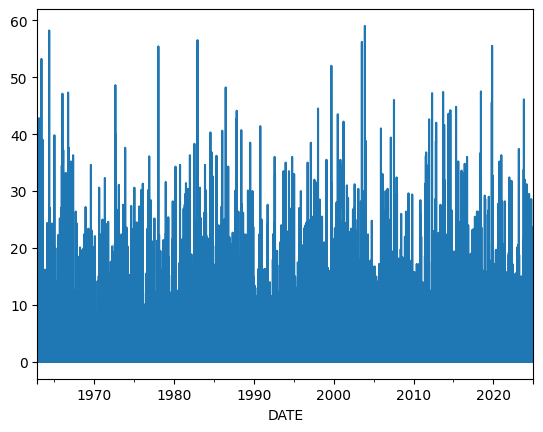

In [66]:
df_poste.set_index('DATE')['RR'].plot(kind = 'line')

1325011   1950-01-01
1325012   1950-01-02
1325013   1950-01-03
1325014   1950-01-04
1325015   1950-01-05
             ...    
1328412   1961-04-26
1328413   1961-04-27
1328414   1961-04-28
1328415   1961-04-29
1328416   1961-04-30
Name: AAAAMMJJ, Length: 3406, dtype: datetime64[ns]